In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la
from itertools import combinations

# -------------------------
# Toy data: 6 items in 2 groups
# -------------------------
labels = ["A", "B", "C", "D", "E", "F"]

X = np.array([
    [1.00, 0.90],   # A
    [0.90, 1.00],   # B
    [0.85, 0.80],   # C
    [-1.00, -0.90], # D
    [-0.90, -1.00], # E
    [-0.80, -0.85], # F
], dtype=float)
print("Original Vectors:\n", X)

# normalize so dot product = cosine similarity
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
print("Normalized Vectors:\n", X_norm)

# cosine similarity matrix
S = X_norm @ X_norm.T
print("Cosine Similarity Matrix:\n", S)

Original Vectors:
 [[ 1.    0.9 ]
 [ 0.9   1.  ]
 [ 0.85  0.8 ]
 [-1.   -0.9 ]
 [-0.9  -1.  ]
 [-0.8  -0.85]]
Normalized Vectors:
 [[ 0.74329415  0.66896473]
 [ 0.66896473  0.74329415]
 [ 0.72819999  0.6853647 ]
 [-0.74329415 -0.66896473]
 [-0.66896473 -0.74329415]
 [-0.6853647  -0.72819999]]
Cosine Similarity Matrix:
 [[ 1.          0.99447514  0.9997516  -1.         -0.99447514 -0.99656768]
 [ 0.99447514  1.          0.99656768 -0.99447514 -1.         -0.9997516 ]
 [ 0.9997516   0.99656768  1.         -0.9997516  -0.99656768 -0.99816514]
 [-1.         -0.99447514 -0.9997516   1.          0.99447514  0.99656768]
 [-0.99447514 -1.         -0.99656768  0.99447514  1.          0.9997516 ]
 [-0.99656768 -0.9997516  -0.99816514  0.99656768  0.9997516   1.        ]]


In [18]:
import faiss

x1 = [1, 2]
x2 = [-2, -1.5]
x3 = [1.5, 2.5]

X = np.array([x1, x2, x3], dtype=float)
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
print("Normalized Vectors:\n", X_norm)

# compute cosine similarity using numpy for upper triangle
for i, j in combinations(range(len(X)), 2):
    sim = X_norm[i] @ X_norm[j]
    if sim > 0.5:  # example threshold
        print(f"Cosine similarity between vector {i} and {j}: {sim:.2f}")

# using faiss to compute cosine similarity
index = faiss.IndexHNSWFlat(2, 32, faiss.METRIC_INNER_PRODUCT)

index.add(X_norm.astype(np.float32))
Sim, I = index.search(X_norm.astype(np.float32), k=2)

I = I[:, 1:]
Sim = Sim[:, 1:]

for i in range(len(X)):
    for j in range(Sim.shape[1]):
        if Sim[i, j] > 0.5:  # example threshold
            print(f"Vectors {i} and {I[i, j]} are similar (cosine similarity: {Sim[i, j]:.2f})")

Normalized Vectors:
 [[ 0.4472136   0.89442719]
 [-0.8        -0.6       ]
 [ 0.51449576  0.85749293]]
Cosine similarity between vector 0 and 2: 1.00
Vectors 0 and 2 are similar (cosine similarity: 1.00)
Vectors 2 and 0 are similar (cosine similarity: 1.00)


In [ ]:
# threshold on cosine distance = 1 - similarity
threshold = 0.05  # strict threshold for a clean toy graph

# Build edges
edges = []
weights = []
for i, j in combinations(range(len(labels)), 2):
    sim = S[i, j]
    cos_dist = 1 - sim
    if cos_dist <= threshold:
        edges.append((i, j))
        weights.append(float(sim))

print("Edges:", edges)
print("Weights:", [round(w, 3) for w in weights])

# Build igraph graph
g = ig.Graph()
g.add_vertices(len(labels))
g.vs["label"] = labels
g.add_edges(edges)
g.es["weight"] = weights

# Leiden partition
partition = la.find_partition(
    g,
    la.RBConfigurationVertexPartition,
    weights=g.es["weight"],
    resolution_parameter=0.5
)

membership = partition.membership
print("Membership:", membership)

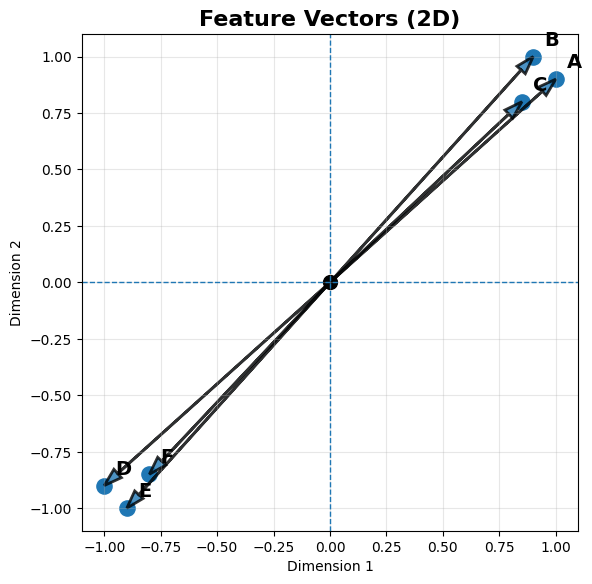

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

# scatter points
ax.scatter(X[:, 0], X[:, 1], s=120)

# arrows from origin
for i, (x, y) in enumerate(X):
    ax.arrow(
        0, 0, x, y,
        length_includes_head=True,
        head_width=0.05,
        head_length=0.08,
        linewidth=2,
        alpha=0.8
    )
    ax.text(x + 0.05, y + 0.05, labels[i], fontsize=14, weight='bold')

# origin marker
ax.scatter([0], [0], s=100, color='black')

ax.axhline(0, linestyle='--', linewidth=1)
ax.axvline(0, linestyle='--', linewidth=1)

ax.set_title("Feature Vectors (2D)", fontsize=16, weight='bold')
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

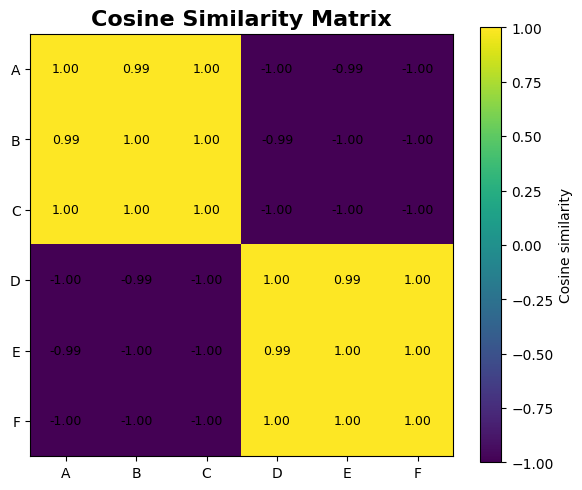

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(S, vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# write values into cells
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Cosine Similarity Matrix", fontsize=16, weight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cosine similarity")

plt.tight_layout()
plt.show()

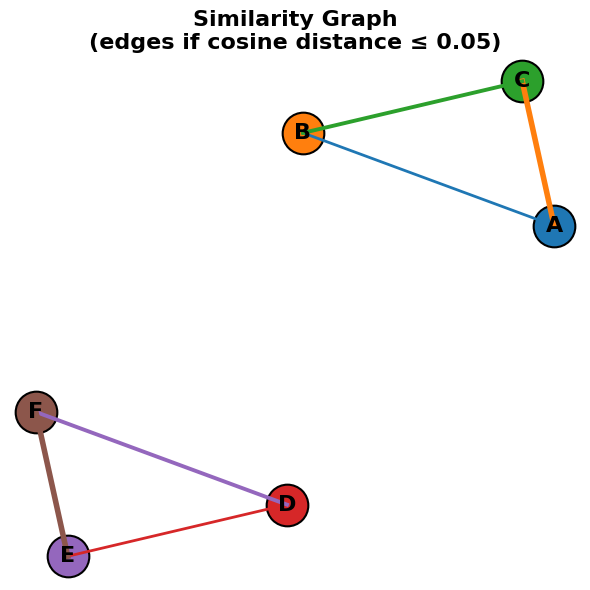

In [6]:
layout = g.layout("fr")  # Fruchterman-Reingold layout

fig, ax = plt.subplots(figsize=(6, 6))

# draw edges
for e, w in zip(g.get_edgelist(), g.es["weight"]):
    i, j = e
    x1, y1 = layout[i]
    x2, y2 = layout[j]
    ax.plot([x1, x2], [y1, y2], linewidth=2 + 2*(w - min(weights)) / (max(weights) - min(weights) + 1e-6))

# draw nodes
for i, (x, y) in enumerate(layout):
    ax.scatter(x, y, s=900, edgecolor="black", linewidth=1.5)
    ax.text(x, y, labels[i], ha="center", va="center", fontsize=16, weight="bold")

ax.set_title(f"Similarity Graph\n(edges if cosine distance ≤ {threshold})", fontsize=16, weight='bold')
ax.axis("off")
plt.tight_layout()
plt.show()

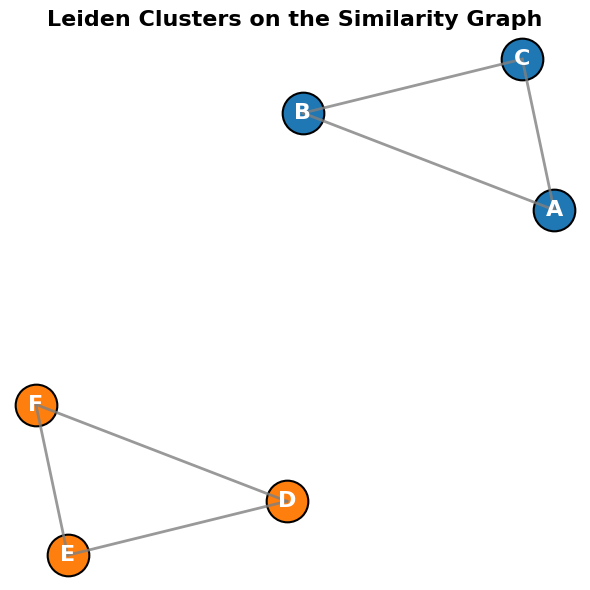

In [7]:
cluster_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, ax = plt.subplots(figsize=(6, 6))

# draw edges first
for e, w in zip(g.get_edgelist(), g.es["weight"]):
    i, j = e
    x1, y1 = layout[i]
    x2, y2 = layout[j]
    ax.plot([x1, x2], [y1, y2], color="gray", linewidth=2, alpha=0.8)

# draw nodes by cluster
for i, (x, y) in enumerate(layout):
    c = cluster_colors[membership[i] % len(cluster_colors)]
    ax.scatter(x, y, s=900, color=c, edgecolor="black", linewidth=1.5)
    ax.text(x, y, labels[i], ha="center", va="center", fontsize=16, weight="bold", color="white")

ax.set_title("Leiden Clusters on the Similarity Graph", fontsize=16, weight='bold')
ax.axis("off")
plt.tight_layout()
plt.show()